In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

from matplotlib.ticker import LogLocator, NullFormatter, MultipleLocator
from matplotlib.gridspec import GridSpec

from scipy.signal import savgol_filter

## Optimum interval alpha limits

In [2]:
def get_all_alpha_limits(sphere, datasets, mphi_lists, method=None):

    mx_list = [[], []]
    alpha_lims = [[], []]
    for i, dataset in enumerate(datasets):
        for mphi in mphi_lists[i]:
            mphi_prefix = f'{mphi:.0e}'

            if sphere == 'sphere_combined' :
                if method is not None:
                    file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_{method}_{dataset}_halodensity_{mphi_prefix}.npz'
                else:
                    file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_{dataset}_halodensity_{mphi_prefix}.npz'
            else:
                file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_{dataset}_halodensity_{mphi_prefix}.npz'

            npz_file = np.load(file)

            mx = npz_file['mx_gev']
            alpha_lim = npz_file['alpha_lim']

            mx_list[i].append(mx)
            alpha_lims[i].append(alpha_lim)

    # Mx for 10, 1, 0.1, 0 eV
    mx_list_ret = [mx_list[0][0], np.concatenate([mx_list[0][1], mx_list[1][0]]), np.concatenate([mx_list[0][2], mx_list[1][1]]), np.concatenate([mx_list[0][3], mx_list[1][2]])]
    alpha_lims_ret = [alpha_lims[0][0], np.concatenate([alpha_lims[0][1], alpha_lims[1][0]]), np.concatenate([alpha_lims[0][2], alpha_lims[1][1]]), np.concatenate([alpha_lims[0][3], alpha_lims[1][2]])]

    return mx_list_ret, alpha_lims_ret

def plot_alpha_lims(ax, mxs, alpha_lims):
    colors = ['#292f56', '#006290', '#0097a3', '#00cf97', '#acfa70']

    for i, mx in enumerate(mxs):
        ax.plot(mx, alpha_lims[i], color=colors[i])

    ax.fill_between(mxs[3], alpha_lims[3], 5e-4, color=colors[3], alpha=0.2)
    ax.fill_between(mxs[2], alpha_lims[2], 5e-4, color=colors[2], alpha=0.2)
    ax.fill_between(mxs[1], alpha_lims[1], 5e-4, color=colors[1], alpha=0.2)
    ax.fill_between(mxs[0], alpha_lims[0], 5e-4, color=colors[0], alpha=0.2)

    return ax

Text(0, 0.5, 'Single neutron coupling, $\\alpha_n$')

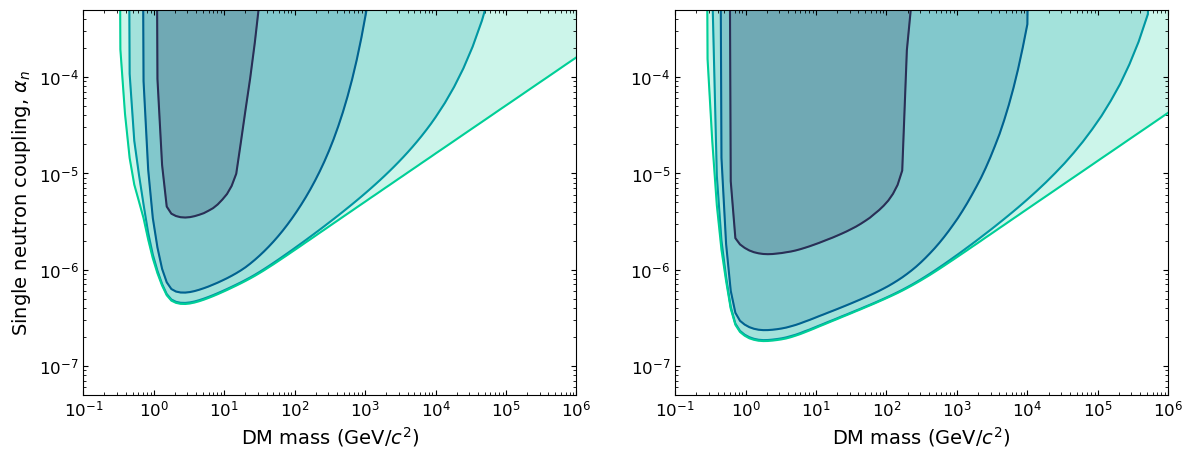

In [3]:
mxs_0, alpha_lims_0 = get_all_alpha_limits('sphere_20241202', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]])
mxs_1, alpha_lims_1 = get_all_alpha_limits('sphere_20250103', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0] = plot_alpha_lims(axes[0], mxs_0, alpha_lims_0)
axes[1] = plot_alpha_lims(axes[1], mxs_1, alpha_lims_1)

for ax in axes:
    ax.set_xlim(1e-1, 1e6)
    ax.set_ylim(5e-8, 5e-4)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'DM mass (GeV/$c^2$)')
    
axes[0].set_ylabel(r'Single neutron coupling, $\alpha_n$')


#### Estimate atmospheric overburden

In [4]:
# Parameters
hbarc = 0.2     # eV um
kg2GeV = 5.61e26
v0 = 1e-3    # DM velocity

m_n = 1e9      # neutron mass (eV)
m_N = m_n * 28 # Nitrogen mass (eV)

m_total_atmosphere = 5.15e18  # total mass of the atmosphere (kg)
n_nitrogen_atmosphere = m_total_atmosphere * kg2GeV / 28   # total number of nitrogen in the atmosphere
r_earth = 6.4e6    # Earth radius (m)
r_nitrogen = 8500 # Nitrogen distribution length (m)

r_earth_ev = r_earth / 1e-6 / hbarc
r_nitrogen_ev = r_nitrogen / 1e-6 / hbarc
n_tot_nitrogen_path = n_nitrogen_atmosphere / (4 * np.pi * r_earth_ev**2)                # total number of nitrogen along the path
n_nitrogen_volume = n_nitrogen_atmosphere / (4 * np.pi * r_earth_ev**2 * r_nitrogen_ev)  # volume number density of nitrogen (eV^-3)

In [5]:
def calc_alpha_n_stop_classical(mx):
    b_min = 1e-5 / hbarc
    b_max = 1 / hbarc

    alpha_n_list = np.logspace(-3, -20, 200)

    stop_fractions = np.empty_like(alpha_n_list)
    for i, alpha_n in enumerate(alpha_n_list):
        alpha = alpha_n * 14  # DM-N2 coupling

        dEdx_classical = n_nitrogen_volume * 4 * np.pi * alpha**2 / (m_N * v0**2) * np.log(b_max / b_min)

        ek_dm = 0.5 * mx * v0**2
        stop_fractions[i] = ek_dm / (dEdx_classical * r_nitrogen_ev)
    return np.interp(1, stop_fractions, alpha_n_list)

def calc_alpha_n_stop(mx, mphi):
    # Assume the very long range interaction would be cut off
    # at the scale of mean free path of air molecule
    # l ~ 100 nm ~ 2 eV-1
    screening_length = 2    # eV-1
    if mphi == 0:
        lamb = screening_length
    else:
        lamb = min(1/mphi, screening_length)
        # lamb = 1 / mphi

    alpha_n_list = np.logspace(-3, -20, 200)
    stop_fractions = np.empty_like(alpha_n_list)

    for i, alpha_n in enumerate(alpha_n_list):
        alpha = alpha_n * 14
        mu_XN = 1 / (1/m_N + 1/mx)

        # Beta parameter for the potential
        beta = alpha / (mu_XN * v0**2 * lamb)
        # Transport cross section
        sigma_transport = 2 * np.pi * lamb**2 * beta**2 * np.log(1 + 1/(beta**2))

        v_cm = v0
        pdot_p = (mu_XN / mx) * n_nitrogen_volume * sigma_transport * v_cm
        delta_t_pass = r_nitrogen_ev / v0

        stop_fractions[i] = 1 / (pdot_p * delta_t_pass)

    return np.interp(1, stop_fractions, alpha_n_list)

In [6]:
mphi_list = [10, 1, 0.1, 0]  # eV
mx_list = np.logspace(-2, 7, 300) * 1e9

alpha_n_stop = np.empty(shape=(len(mphi_list), mx_list.size))
for i, mphi in enumerate(mphi_list):
    for j, mx in enumerate(mx_list):
        alpha_n_stop[i, j] = calc_alpha_n_stop(mx, mphi)

alpha_n_stop_classical = np.empty_like(mx_list)
for i, mx in enumerate(mx_list):
    alpha_n_stop_classical[i] = calc_alpha_n_stop_classical(mx)

#### Combined alpha limits

In [7]:
def get_masked_usphere_lim(usphere_lim, nanosphere_lim):
    mask = usphere_lim > nanosphere_lim
    masked_usphere_lim = np.where(mask, np.nan, usphere_lim)

    return masked_usphere_lim

In [8]:
# Load the combined limits
mxs_cl, alpha_lims_cl = get_all_alpha_limits('sphere_combined', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]], method=None)
mxs_cl_serial, alpha_lims_cl_serial = get_all_alpha_limits('sphere_combined', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]], method='serialization')
mxs_cl_minlim, alpha_lims_cl_minlim = get_all_alpha_limits('sphere_combined', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]], method='minlim')

# Load the microsphere limits
usphere_lim_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/other_limits/microsphere_limits_2020'
mphi_usphere = [1, 0.1, 0.01, 0]

mx_usphere, alpha_lim_usphere = [], []
for mphi in mphi_usphere:
    npz_file = np.load(f'{usphere_lim_dir}/limits_mphi_{mphi:.0e}_nugg_frac_1.00e+00.npz')
    mx_usphere.append(npz_file['x'])
    alpha_lim_usphere.append(npz_file['y'])

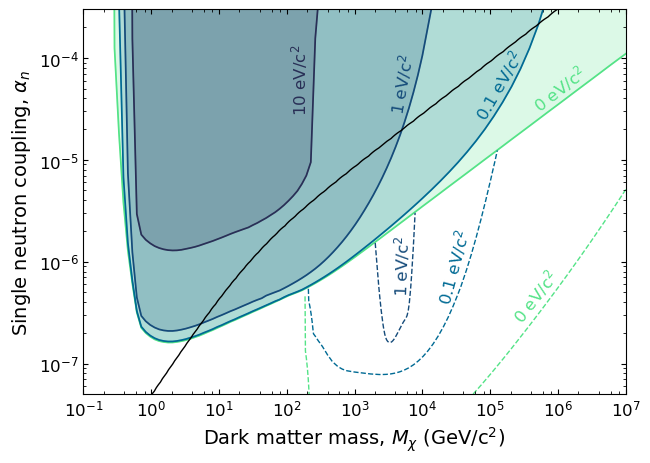

In [18]:
colors = ['#292f56', '#154b7a', '#006a94', '#00889f', '#00a6a4', '#00c79c', '#54e387']


# Resample microsphere limits for plotting
mx_fine = np.logspace(1, 8, 5000)
alpha_lim_usphere_1ev = np.interp(mx_fine, mx_usphere[0], alpha_lim_usphere[0], left=np.nan, right=np.nan)
alpha_lim_usphere_0_1ev = np.interp(mx_fine, mx_usphere[1], alpha_lim_usphere[1], left=np.nan, right=np.nan)
alpha_lim_usphere_0ev = np.interp(mx_fine, mx_usphere[3], alpha_lim_usphere[3], left=np.nan, right=np.nan)

alpha_lim_combined_dm_0ev_fine = np.interp(mx_fine, mxs_cl_serial[3], alpha_lims_cl_serial[3], left=np.nan, right=np.nan)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# ax.plot(mxs_cl[0], alpha_lims_cl[0], '-', color=colors[0], label=r'$m_\phi$ = 10 eV', linewidth=1.25)
# ax.plot(mxs_cl[1], alpha_lims_cl[1], '-', color=colors[1], label=r'$m_\phi$ = 1 eV', linewidth=1.25)
# ax.plot(mxs_cl[2], alpha_lims_cl[2], '-', color=colors[2], label=r'$m_\phi$ = 0.1 eV', linewidth=1.25)
# ax.plot(mxs_cl[3], alpha_lims_cl[3], '-', color=colors[6], label=r'$m_\phi$ = 0 eV', linewidth=1.25, zorder=-5)

ax.plot(mxs_cl_serial[0], alpha_lims_cl_serial[0], '-', color=colors[0], label=r'$m_\phi$ = 10 eV', linewidth=1.25)
ax.plot(mxs_cl_serial[1], alpha_lims_cl_serial[1], '-', color=colors[1], label=r'$m_\phi$ = 1 eV', linewidth=1.25)
ax.plot(mxs_cl_serial[2], alpha_lims_cl_serial[2], '-', color=colors[2], label=r'$m_\phi$ = 0.1 eV', linewidth=1.25)
ax.plot(mxs_cl_serial[3], alpha_lims_cl_serial[3], '-', color=colors[6], label=r'$m_\phi$ = 0 eV', linewidth=1.25, zorder=-5)

ax.plot(mx_fine, get_masked_usphere_lim(alpha_lim_usphere_1ev, alpha_lim_combined_dm_0ev_fine), '--', color=colors[1], alpha=1, linewidth=1, zorder=-5)
ax.plot(mx_fine, get_masked_usphere_lim(alpha_lim_usphere_0_1ev, alpha_lim_combined_dm_0ev_fine), '--', color=colors[2], alpha=1, linewidth=1, zorder=-5)
ax.plot(mx_fine, get_masked_usphere_lim(alpha_lim_usphere_0ev, alpha_lim_combined_dm_0ev_fine), '--', color=colors[6], alpha=1, linewidth=1, zorder=-5)

ax.fill_between(mxs_cl_serial[3], alpha_lims_cl_serial[3], 5e-4, color=colors[6], alpha=0.2)
ax.fill_between(mxs_cl_serial[2], alpha_lims_cl_serial[2], 5e-4, color=colors[2], alpha=0.2)
ax.fill_between(mxs_cl_serial[1], alpha_lims_cl_serial[1], 5e-4, color=colors[1], alpha=0.2)
ax.fill_between(mxs_cl_serial[0], alpha_lims_cl_serial[0], 5e-4, color=colors[0], alpha=0.2)

ax.text(3.75e5, 3e-5, r'0 eV/c$^2$', color=colors[6], rotation=38, fontsize=12)
ax.text(5.25e4, 2.5e-5, r'0.1 eV/c$^2$', color=colors[2], rotation=60, fontsize=12)
ax.text(3e3, 3e-5, r'1 eV/c$^2$', color=colors[1], rotation=80, fontsize=12)
ax.text(1.1e2, 3e-5, r'10 eV/c$^2$', color=colors[0], rotation=90, fontsize=12)

ax.text(1.85e5, 2.5e-7, r'0 eV/c$^2$', color=colors[6], rotation=52, fontsize=12)
ax.text(1.5e4, 4e-7, r'0.1 eV/c$^2$', color=colors[2], rotation=75, fontsize=12)
ax.text(3.4e3, 5e-7, r'1 eV/c$^2$', color=colors[1], rotation=88, fontsize=12)

ax.plot(mx_list/1e9, alpha_n_stop[1], 'k-', linewidth=1)
# ax.text(0.15, 1.5e-7, 'Atmospheric\noverburden', fontsize=12)

plt.xlim(1e-1, 1e7)
plt.ylim(5e-8, 3e-4)
plt.xscale('log')
plt.yscale('log')

locmaj = LogLocator(base=10, numticks=11) 
ax.xaxis.set_major_locator(locmaj)
locmin = LogLocator(base=10.0,subs=(0.2,0.4,0.6,0.8),numticks=11)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(NullFormatter())

plt.xlabel(r'Dark matter mass, $M_\chi$ (GeV/c$^2$)')
plt.ylabel(r'Single neutron coupling, $\alpha_n$')

plt.savefig('../paper_plots/combined_alpha_limits.pdf', dpi=600)

#### Get a projective limit for SQL sensitivity with an array

In [10]:
sigma_sql = 23.72
exposure_arr = 100 * 30 * 24 * 3600  # s
exposure_sphere = 1 * 30 * 24 * 3600  # s
threshold = sigma_sql * 5 # keV

mphi = '1e+00'
drdqzn_file = rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/drdqz_100mevthr_nanosphere_8.30e-02_projection_sqlproj_{mphi}.npz'
_drdqzn = np.load(drdqzn_file)

q_kev = _drdqzn['bc_kev']
drdqzn = _drdqzn['drdqzn']

mx_list_proj = _drdqzn['mx_list']
alpha_list_proj = _drdqzn['alpha_list']

n_events_arr = np.empty(shape=(mx_list_proj.size, alpha_list_proj.size))
n_events_sphere = np.empty(shape=(mx_list_proj.size, alpha_list_proj.size))

for i, mx in enumerate(mx_list_proj):
    for j, alpha in enumerate(alpha_list_proj):
        rate = drdqzn[i, j]
        n_events_arr[i, j] = exposure_arr * np.trapz(rate[q_kev>threshold], q_kev[q_kev>threshold])
        n_events_sphere[i, j] = exposure_sphere * np.trapz(rate[q_kev>threshold], q_kev[q_kev>threshold])

In [11]:
# 95% CL background free projection
alpha_lim_sphere_sql, alpha_lim_arr_sql = np.empty_like(mx_list_proj), np.empty_like(mx_list_proj)
for i, mx in enumerate(mx_list_proj):
    alpha_lim_arr_sql[i] = np.interp(3, n_events_arr[i], alpha_list_proj)
    alpha_lim_sphere_sql[i] = np.interp(3, n_events_sphere[i], alpha_list_proj)

    if alpha_lim_arr_sql[i] == alpha_list_proj[-1]:
        alpha_lim_arr_sql[i] = np.nan
    if alpha_lim_sphere_sql[i] == alpha_list_proj[-1]:
        alpha_lim_sphere_sql[i] = np.nan

## Composite dark matter limits

In [12]:
c = 3e5
c_cm = 3e10  # cm/s
v0 = 220 / c
mN = 1
q0 = v0 * 1

sub_component_frac = 1
def get_dm_xsec(mX, mchi, Eth, mN, nevts, target_mass, expos):
    """
    Approximate cross section limits for direct detection experiments
    
    Parameters:
    mX: DM mass in GeV
    mchi: DM constituent mass in GeV
    Eth: energy threshold in GeV
    mN: *nucleus* mass in GeV
    nevts: number of events to set the 95% CL limits
    target_mass: kg
    expos: exposure in seconds
    """
    
    A = 1.0 * mN ## number of nucleons
    mnuc = 1

    gtgx = 1
    rhoX = 0.3 * sub_component_frac ## GeV/cm^3

    NX = mX/mchi
    mu = (mX * mN)/(mX + mN)
    
    Rx = (9*np.pi/4 * mX/mchi**4)**(1/3)
    sig0 = NX**2 * gtgx**2 * mu**2

    nT = (target_mass * 1e3) / A * 6.02e23
    sigtot_lim = (nevts / (nT * expos)) / ( rhoX/mX * v0 * c_cm) # in cm^2

    ### Below is incorrect
    # sigXn12 = sigtot_lim * (8 * Eth * v0**2 * mnuc**3) / (A * q0**4)
    # sigXn3 = sigtot_lim * (64 * A * Rx**4 * v0**2 * mnuc**5 * Eth**3)/(3 * q0**4)
    # sigXtot = 1.0*sigXn12

    # gidx3 = mX > np.sqrt(2) * mchi/(9*np.pi) * (mchi**2/(mN * Eth))**(3/2)
    # sigXtot[gidx3] = sigXn3[gidx3]
    
    ### My implementation
    q_min = np.sqrt(2 * A * mnuc * Eth)
    q_max = np.min([2*mX*v0, 2*np.full_like(mX, mN)*v0], axis=0)
    
    mu_chi_n = (mX * mnuc) / (mX + mnuc)
    sigXtot = sigtot_lim * 4 * v0**2 * mu_chi_n**2 / ( A**2 * q0**4 * (1/(q_min**2) - 1/(q_max**2)) )
    sigXn3 = sigtot_lim * 8 * Rx**4 * v0**2 * mu_chi_n**2 / (3 * A**2 * q0**4 * (1/(q_min**6) - 1/(q_max**6)) )

    gidx3 = mX > np.sqrt(2) * mchi/(9*np.pi) * (mchi**2/(mN * Eth))**(3/2)
    sigXtot[gidx3] = sigXn3[gidx3]

    # When `q_min` > `q_max` will become negative
    # That means the maximum momentum transfer is below the detectable threshold
    sigXtot[sigXtot < 0] = np.nan
    
    return sigXtot

In [13]:
convert_factor = 0.3894e-27 / 1e-18  # 1 / eV^2 -> cm^2
mn_ev = 939.565e6                    # neutron mass (eV)

def get_sphere_sigma_n(mx, mphi, yn, yx_lim='unity', yx=None):    
    # Input mx in eV (array-like)
    # Note that we parametrize the cross section in a way slightly
    # different from the composite dm paper
    # -- there is a (small) factor of mediator mass squared
    # -- reference momentum transfer is chosen as v_dm * mn

    sig_n = np.empty_like(mx)
    if yx_lim == 'unity':
        yx = 1
    else:
        raise('Other ychi choices not implemented')
        
    # DM-neutron reduced mass
    mu_xn = mx * mn_ev / (mx + mn_ev)

    # Cross section in cm^2
    # `1e-3 * mu_xn` is the reference momentum transfer 
    # sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mx)**2)**2)
    # sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * ((1e-3 * mn_ev)**2)**2)
    sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mu_xn)**2)**2)

    return sig_n

In [14]:
fifth_force_lim = np.genfromtxt('../other_limits/fifth_force_lim_ev.csv', delimiter=' ', skip_header=1).T
n_xe_lim = np.genfromtxt('../other_limits/n_xe_yn_lim.csv', delimiter=',').T
stellar_cooling_lim = np.genfromtxt('../other_limits/stellar_cooling_yn_lim.csv', delimiter=',').T
sn1987a_lim = np.genfromtxt('../other_limits/sn1987a_yn_lim_lower.csv', delimiter=',').T

# DM mass in MeV
sidm_yx_lim     = np.genfromtxt('../other_limits/sidm_yx_lim.csv', delimiter=',').T
sidm_yx_lim[0]  = sidm_yx_lim[0] * 1e6  # Convert MeV to eV

def get_fifth_force_sigma_n(mx, mphi, lim='fifth_force', yx_lim='unity', Nx=1):
    # Input mx in eV (array-like)
    dat = None
    if lim == 'fifth_force':
        dat = fifth_force_lim
    elif lim == 'n_xe':
        dat = n_xe_lim
    elif lim == 'stellar_cooling':
        dat = stellar_cooling_lim
    elif lim == 'sn1987a':
        dat = sn1987a_lim
    
    idx_sorted = np.argsort(dat[0])
    yn   = 10**np.interp(np.log10(mphi), np.log10(dat[0][idx_sorted]), np.log10(dat[1][idx_sorted]), right=np.nan)
    # print(yn)

    if yx_lim == 'SIDM':
        yx = 10**np.interp(np.log10(mx), np.log10(sidm_yx_lim[0]), np.log10(sidm_yx_lim[1]))
    elif yx_lim == 'unity':
        yx = 1
    elif yx_lim == 'root4pi':
        yx = np.sqrt(4 * np.pi)
    
    # DM-neutron reduced mass
    mu_xn = mx * mn_ev / (mx + mn_ev)

    # Cross section in cm^2
    # sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mx)**2)**2)
    # sig_n = convert_factor * Nx**2 * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * ((1e-3 * mn_ev)**2)**2)
    sig_n = convert_factor * Nx**2 * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mu_xn)**2)**2)
    
    return sig_n

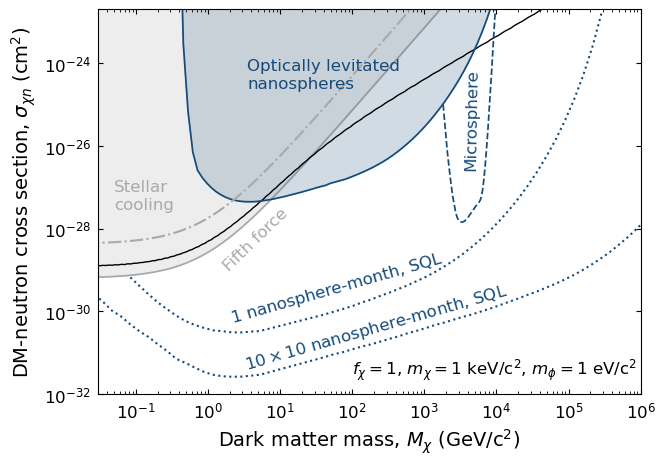

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

mx_fine = np.logspace(1, 8, 5000)
mx_list_coarse = mxs_cl_serial[1]
alpha_lim_combined_dm_1ev = alpha_lims_cl_serial[1]

mx_plot_gev = np.logspace(-2, 7, 2000)
mx_plot = mx_plot_gev * 1e9

mmx = 1000               # DM constituent mass (eV)
nx = mx_plot / mmx       # Number of DM constituent      
mphi = 1

yn_lim_nanosphere_1ev = 4 * np.pi * alpha_lim_combined_dm_1ev
yn_lim_nanosphere_sql_1ev = 4 * np.pi * alpha_lim_sphere_sql
yn_lim_nanosphere_arr_sql_1ev = 4 * np.pi * alpha_lim_arr_sql
sigman_lim_nanosphere_1ev = get_sphere_sigma_n(mx_list_coarse*1e9, mphi, yn_lim_nanosphere_1ev)
sigman_lim_nanosphere_sql_1ev = get_sphere_sigma_n(mx_list_proj*1e9, mphi, yn_lim_nanosphere_sql_1ev)
sigman_lim_nanosphere_arr_sql_1ev = get_sphere_sigma_n(mx_list_proj*1e9, mphi, yn_lim_nanosphere_arr_sql_1ev)

sigman_lim_nanosphere_1ev_fine = np.interp(mx_fine, mx_list_coarse, sigman_lim_nanosphere_1ev)
sigman_atmosphere_overburden = get_sphere_sigma_n(mx_list, mphi, 4 * np.pi * alpha_n_stop[1])

yn_lim_usphere_1ev = 4 * np.pi * alpha_lim_usphere_1ev
sigman_lim_usphere_1ev = get_sphere_sigma_n(mx_fine*1e9, mphi, yn_lim_usphere_1ev)
sigman_lim_usphere_1ev = get_masked_usphere_lim(sigman_lim_usphere_1ev, sigman_lim_nanosphere_1ev_fine)

sigman_lim_fifth_force_1ev = get_fifth_force_sigma_n(mx_plot, mphi, lim='fifth_force', yx_lim='unity', Nx=nx)

# Start plotting
bad_idx = np.array([30, 31, 32, 33, 34, 35])
_idx_plot     = np.arange(0, 79, 1)
idx_plot = np.delete(_idx_plot, bad_idx)

ax.loglog(mx_list_proj[idx_plot[15:]], sigman_lim_nanosphere_sql_1ev[idx_plot[15:]], ':', linewidth=1.5, color=colors[1], markersize=2)
ax.loglog(mx_list_proj[idx_plot], sigman_lim_nanosphere_arr_sql_1ev[idx_plot], ':', linewidth=1.5, color=colors[1], markersize=2)

ax.loglog(mx_list/1e9, sigman_atmosphere_overburden, 'k-', linewidth=1)

ax.loglog(mx_fine, sigman_lim_usphere_1ev, '--', linewidth=1.25, color=colors[1])

ax.loglog(mx_list_coarse, sigman_lim_nanosphere_1ev, linewidth=1.25, color=colors[1])
ax.fill_between(mx_list_coarse, sigman_lim_nanosphere_1ev, 1e-20, color=colors[1], alpha=0.2)

ax.loglog(mx_plot_gev, sigman_lim_fifth_force_1ev, linewidth=1.25, zorder=-5, color='darkgrey')
ax.fill_between(mx_plot_gev, sigman_lim_fifth_force_1ev, 1e-20, color='darkgrey', alpha=0.2)

ax.loglog(mx_plot_gev, get_fifth_force_sigma_n(mx_plot, mphi, 'stellar_cooling', 'unity', nx), '-.', linewidth=1.5, color='darkgrey')

# ax.loglog(mx_plot/1e9, get_dm_xsec(mx_plot/1e9, mmx/1e9, 5000e-9, 130, 3/0.05, 1000, np.pi * 1e7), label='XENON1T 1000 kg-yr', linewidth=1)
# ax.loglog(mx_plot/1e9, get_dm_xsec(mx_plot/1e9, mmx/1e9, 500e-9, 73, 10/0.05, 0.2, np.pi * 1e7), label='CDMSlite 0.2 kg-yr', linewidth=1)

ax.text(1.5, 1e-29, 'Fifth force', color='darkgrey', rotation=44, fontsize=12)
ax.text(5e-2, 3e-28, 'Stellar\ncooling', color='darkgrey', rotation=0, fontsize=12)

ax.text(3.5, 2.5e-25, 'Optically levitated\nnanospheres', color=colors[1], rotation=0, fontsize=12)
ax.text(3.5e3, 3e-27, 'Microsphere', color=colors[1], rotation=89, fontsize=12)

ax.text(2, 5.5e-31, r'1 nanosphere-month, SQL', color=colors[1], rotation=16, fontsize=12)
ax.text(3, 4e-32, r'$10\times10$ nanosphere-month, SQL', color=colors[1], rotation=16, fontsize=12)

ax.set_xlabel(r'Dark matter mass, $M_\chi$ (GeV/c$^2$)', fontsize=14)
ax.set_ylabel(r'DM-neutron cross section, $\sigma_{\chi n}$ ($\mathrm{cm}^2$)', fontsize=14)

ax.text(1e2, 3e-32, fr'$f_\chi=1$, $m_\chi=1$ keV/c$^2$, $m_\phi={int(mphi)}$ eV/c$^2$', fontsize=12)

ax.set_xlim(3e-2, 1e6)
ax.set_ylim(1e-32, 2e-23)

ax.tick_params(right=True, top=True, labelright=False, labeltop=False, labelrotation=0)
ax.tick_params(axis='both', which='both', direction="in", pad=5, labelsize=12)

plt.savefig('../paper_plots/composite_dm_limits.pdf', dpi=600)

#### Thermalized DM limits (halo number density)

In [37]:
mphi_list = [0, 1e-5, 1e-4, 1e-3, 1e-2]

mxs_halo = []
alpha_lims_halo = []
for mphi in mphi_list:
    outfile = rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_minlim_sphere_combined_serialization_thermalized_dm_halodensity_{mphi:.0e}.npz'
    npz = np.load(outfile)

    mx = npz['mx_gev']
    alpha_lim = npz['alpha_lim']

    mxs_halo.append(mx)
    alpha_lims_halo.append(alpha_lim)

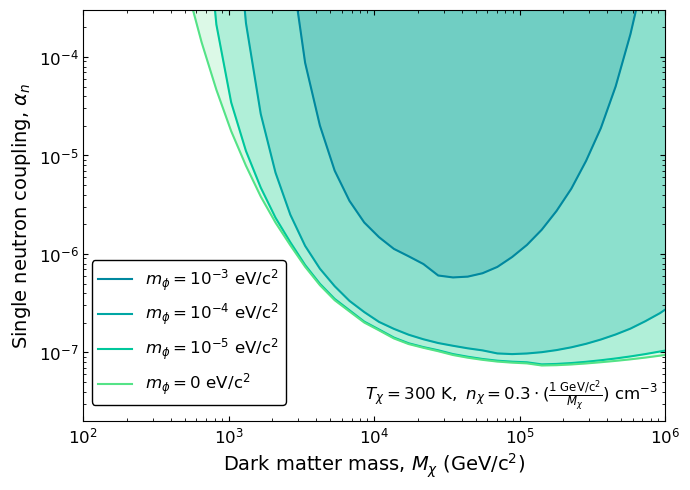

In [40]:
colors = ['#292f56', '#154b7a', '#006a94', '#00889f', '#00a6a4', '#00c79c', '#54e387']

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.plot(mxs_halo[3], alpha_lims_halo[3], '-', color=colors[3], label=r'$m_\phi = 10^{-3}$ eV/c$^2$')
ax.plot(mxs_halo[2], alpha_lims_halo[2], '-', color=colors[4], label=r'$m_\phi = 10^{-4}$ eV/c$^2$')
ax.plot(mxs_halo[1], alpha_lims_halo[1], '-', color=colors[5], label=r'$m_\phi = 10^{-5}$ eV/c$^2$')
ax.plot(mxs_halo[0], alpha_lims_halo[0], '-', color=colors[6], label=r'$m_\phi = 0$ eV/c$^2$')

ax.fill_between(mxs_halo[0], alpha_lims_halo[0], 1e-1, color=colors[6], alpha=0.2)
ax.fill_between(mxs_halo[1], alpha_lims_halo[1], 1e-1, color=colors[5], alpha=0.2)
ax.fill_between(mxs_halo[2], alpha_lims_halo[2], 1e-1, color=colors[4], alpha=0.2)
ax.fill_between(mxs_halo[3], alpha_lims_halo[3], 1e-1, color=colors[3], alpha=0.2)

# ax.text(3e5, 4e-8, '0 eV', color=colors[6], rotation=8, fontsize=12)
# ax.text(1.5e5, 1.75e-7, r'$10^{-5}$ eV', color=colors[5], rotation=20, fontsize=12)
# ax.text(1e5, 6e-7, '$10^{-4}$ eV', color=colors[4], rotation=55, fontsize=12)
# ax.text(1.6e5, 1e-5, '$10^{-3}$ eV', color=colors[3], rotation=70, fontsize=12)
plt.legend(frameon=True, loc='lower left', bbox_to_anchor=[0, 0.02],fontsize=12, edgecolor='k', framealpha=1)

plt.xlim(1e2, 1e6)
plt.ylim(2e-8, 3e-4)

plt.xscale('log')
plt.yscale('log')

plt.text(8e3, 3.25e-8, r'$\ T_\chi = 300 \ \mathrm{K}, \ n_\chi = 0.3 \cdot (\frac{1 \ \mathrm{GeV/c^2}}{M_\chi}) \ \mathrm{cm}^{-3}$', fontsize=12)
plt.xlabel(r'Dark matter mass, $M_\chi$ (GeV/c$^2$)')
plt.ylabel(r'Single neutron coupling, $\alpha_n$')

plt.tight_layout()
plt.savefig('../paper_plots/thermalized_dm_alpha_limits_halo_density.pdf', dpi=600)

## Plot the reconstructed histograms

In [41]:
# out_dir = r'C:\Users\yuhan\dm_nanospheres\data_processed\sphere_data'
out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data'

outfile_name = 'sphere_20241202_recon_all_bg.h5py'
with h5py.File(os.path.join(out_dir, outfile_name), 'r') as fout:
    g = fout['recon_data_all']
    bc_0 = g['bc'][:]

    hist_all_0 = g['hist_all'][:]
    hist_det_0 = g['hist_det'][:]
    hist_det_noise_0 = g['hist_det_noise'][:]
    hist_det_noise_chi2_0 = g['hist_det_noise_chi2'][:]
    hist_det_noise_bg_0 = g['hist_det_noise_bg'][:]
    hist_det_noise_chi2_bg_0 = g['hist_det_noise_chi2_bg'][:]
    livetime_0 = g.attrs['livetime_sec']

    fout.close()

outfile_name = 'sphere_20250103_recon_all_bg.h5py'
with h5py.File(os.path.join(out_dir, outfile_name), 'r') as fout:
    g = fout['recon_data_all']
    bc_1 = g['bc'][:]

    hist_all_1 = g['hist_all'][:]
    hist_det_1 = g['hist_det'][:]
    hist_det_noise_1 = g['hist_det_noise'][:]
    hist_det_noise_chi2_1 = g['hist_det_noise_chi2'][:]
    hist_det_noise_bg_1 = g['hist_det_noise_bg'][:]
    hist_det_noise_chi2_bg_1 = g['hist_det_noise_chi2_bg'][:]
    livetime_1 = g.attrs['livetime_sec']

    fout.close()

amp2kev_sphere_20241202 = 5945.245097647231
amp2kev_sphere_20250103 = 5923.2059527417405
file0 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20241202_unbinned_amps_bg.h5py')
file1 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20250103_unbinned_amps_bg.h5py')

amps0 = file0['unbinned_amps']['amplitude'][:]
amps1 = file1['unbinned_amps']['amplitude'][:]
file0.close()
file1.close()

amps_kev_0 = np.abs(amps0 * amp2kev_sphere_20241202)
amps_kev_1 = np.abs(amps1 * amp2kev_sphere_20250103)


In [42]:
frac_det = (np.sum(hist_all_0 - hist_det_0) + np.sum(hist_all_1 - hist_det_1)) / (np.sum(hist_all_0) + np.sum(hist_all_1))
frac_noise = (np.sum(hist_det_0 - hist_det_noise_0) + np.sum(hist_det_1 - hist_det_noise_1)) / (np.sum(hist_det_0) + np.sum(hist_det_1))
frac_bg = (np.sum(hist_det_noise_0 - hist_det_noise_bg_0) + np.sum(hist_det_noise_1 - hist_det_noise_bg_1)) / (np.sum(hist_det_noise_0) + np.sum(hist_det_noise_1))

print(f'Percentage of livetime cut by detection quality cut: {frac_det*100:.2f}%')
print(f'Percentage of livetime cut by noise level cut: {frac_noise*100:.2f}%')
print(f'Percentage of livetime cut by background event cut: {frac_bg*100:.2f}%')
print(f'Total livetime: {(livetime_0 + livetime_1) / 3600 / 24:.2f} days')

Percentage of livetime cut by detection quality cut: 4.70%
Percentage of livetime cut by noise level cut: 8.64%
Percentage of livetime cut by background event cut: 7.03%
Total livetime: 26.09 days


#### Get the DM rates at 95% CL upper limit

In [43]:
mphi = 1
drdqzn_file = rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/drdqz_100mevthr_nanosphere_8.30e-02_coarse_ampdepsigma_{mphi:.0e}.npz'
_drdqzn = np.load(drdqzn_file)

q_kev = _drdqzn['bc_kev']
drdqzn = _drdqzn['drdqzn']
mx_list = _drdqzn['mx_list']
alpha_list = _drdqzn['alpha_list']

def get_dm_rate_95cl_lim(mx, alpha, mx_list, alpha_list, bc, drdqzns):
    i_mx = np.argmin(np.abs(mx_list - mx))

    # First index larger than alpha
    j_alpha = np.nonzero(alpha_list > alpha)[0][0]
    i_alpha = j_alpha - 1
    d_alpha = alpha_list[j_alpha] - alpha_list[i_alpha]

    _drdqzn_i = drdqzns[i_mx, i_alpha]
    _drdqzn_j = drdqzns[i_mx, j_alpha]

    # Interpolate between the two rates to the input alpha
    ret = _drdqzn_i + (alpha - alpha_list[i_alpha]) * (_drdqzn_j - _drdqzn_i) / d_alpha

    return bc, ret

In [45]:
mx_0, alpha_0 = 0.52927845, 1.23615687e-06
mx_1, alpha_1 = 1.77827941, 2.09208511e-07
mx_2, alpha_2 = 4688.70200467, 1.74604488e-05

qq_0, drdqzn_0 = get_dm_rate_95cl_lim(mx_0, alpha_0, mx_list, alpha_list, q_kev, drdqzn)
qq_1, drdqzn_1 = get_dm_rate_95cl_lim(mx_1, alpha_1, mx_list, alpha_list, q_kev, drdqzn)
qq_2, drdqzn_2 = get_dm_rate_95cl_lim(mx_2, alpha_2, mx_list, alpha_list, q_kev, drdqzn)

In [46]:
from scipy.special import erf

def get_cut_eff(x, thr, eff):
    ret = np.empty_like(x)
    ret[x < thr] = 0
    ret[x >= thr] = eff

    return ret

def func2(x, z, f):
    return 0.5 * erf((x - z) * f) + 0.5

outfile_name = 'sphere_combined_calibration.h5py'
out_dir = '/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/calibration'

with h5py.File(os.path.join(out_dir, outfile_name), 'r') as fout:
    eff_params_0 = fout['calibration_sphere_20241202']['sig_efficiency_fit_params'][:]
    eff_params_err_0 = fout['calibration_sphere_20241202']['err_sig_efficiency_fit_params'][:]

    eff_0 = fout['calibration_sphere_20241202']['sig_efficiency'][:]
    eff_err_0 = fout['calibration_sphere_20241202']['err_sig_efficiency'][:]

    pulseamps = fout['calibration_sphere_20241202']['pulse_amps'][:]

    eff_params_1 = fout['calibration_sphere_20250103']['sig_efficiency_fit_params'][:]
    eff_params_err_1 = fout['calibration_sphere_20250103']['err_sig_efficiency_fit_params'][:]

    eff_1 = fout['calibration_sphere_20250103']['sig_efficiency'][:]
    eff_err_1 = fout['calibration_sphere_20250103']['err_sig_efficiency'][:]

    fout.close()

det_eff_avg = (eff_0*livetime_0 + eff_1*livetime_1)/(livetime_0 + livetime_1)
det_eff_err_avg = (eff_err_0*livetime_0 + eff_err_1*livetime_1)/(livetime_0 + livetime_1)
pulseamps_err = pulseamps * 11/106

eff = 0.9538018099684543
sigma_cut_eff = 0.023024753091401955

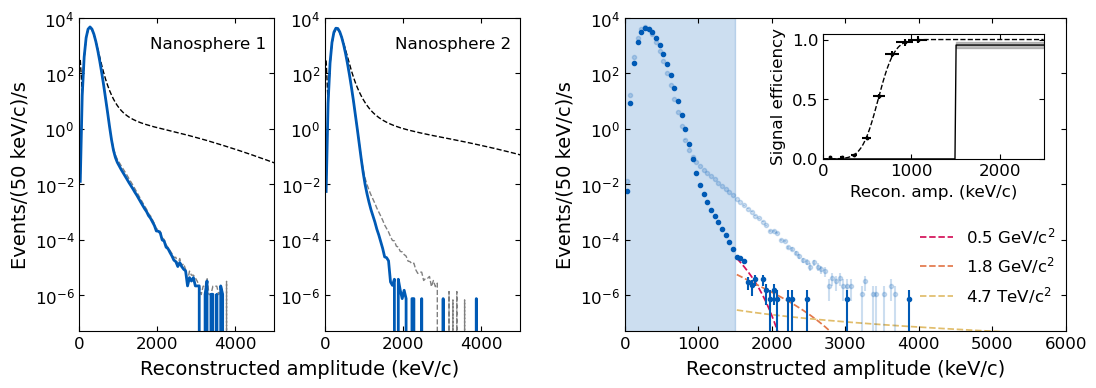

In [55]:
time_per_search = 50e-6
threshold = 1500

# fig, (ax0, ax1, ax2) = plt.subplots(1, 3, width_ratios=[1, 1, 2], figsize=(11, 4))
fig = plt.figure(figsize=(10, 4))
subfigs = fig.subfigures(1, 2, wspace=0.2, width_ratios=(1, 1))
ax0, ax1 = subfigs[0].subplots(1, 2)
ax2 = subfigs[1].subplots(1, 1)

ax0.plot(bc_0, hist_all_0 / (np.sum(hist_all_0)*time_per_search) , 'k', linestyle='--', linewidth=1, label='All events')
ax0.plot(bc_0, hist_det_noise_0 / (np.sum(hist_det_noise_0)*time_per_search), 'grey', linestyle='--', linewidth=1, label='Livetime selection')
ax0.plot(bc_0, hist_det_noise_chi2_bg_0 / livetime_0, color='#005AB5', linewidth=2, label='All cuts')

ax1.plot(bc_1, hist_all_1 / (np.sum(hist_all_1)*time_per_search), 'k', linestyle='--', linewidth=1, label='No cut')
ax1.plot(bc_1, hist_det_noise_1 / (np.sum(hist_det_noise_1)*time_per_search), 'grey', linestyle='--', linewidth=1, label='After initial livetime selections')
ax1.plot(bc_1, hist_det_noise_chi2_bg_1 / livetime_1, color='#005AB5', linewidth=2)

ax0.text(1800, 8e2, 'Nanosphere 1', fontsize=12)
ax1.text(1800, 8e2, 'Nanosphere 2', fontsize=12)

for ax in [ax0, ax1]:
    ax.set_xlim(0, 5000)
    ax.set_ylim(5e-8, 1e4)
    ax.set_yscale('log')

# Plot signal efficiency in the inset
xx = np.linspace(0, 2500, 200)

det_eff_fit_avg = (func2(xx, *eff_params_0) * livetime_0 + func2(xx, *eff_params_1) * livetime_1) / (livetime_0 + livetime_1)
# cut_eff = np.full_like(xx, eff)
cut_eff = get_cut_eff(xx, threshold, eff)
eff_all = det_eff_fit_avg * cut_eff

inset_ax = ax2.inset_axes([0.45, 0.55, 0.5, 0.4])
inset_ax.errorbar(pulseamps, det_eff_avg, xerr=pulseamps_err, yerr=det_eff_err_avg, fmt='.', color='k', markersize=3.5)
inset_ax.plot(xx, det_eff_fit_avg, 'k--', linewidth=1)
inset_ax.plot(xx, eff_all, 'k', linewidth=1)
inset_ax.fill_between(x=xx[xx>threshold], y1=(eff_all[xx>threshold]+sigma_cut_eff), y2=(eff_all[xx>threshold]-sigma_cut_eff), color='grey', alpha=0.5)
# inset_ax.fill_betweenx(np.linspace(0, 1e5, 200), 0, 1250, color='#005AB5', alpha=0.2)

inset_ax.set_xlabel('Recon. amp. (keV/c)', fontsize=12)
inset_ax.set_ylabel('Signal efficiency', fontsize=12)
inset_ax.set_xlim(0, 2500)
inset_ax.set_ylim(0, 1.05)

ax2.plot(qq_0[qq_0 > threshold], drdqzn_0[qq_0 > threshold] * eff * 50, '--', linewidth=1.25, color='#d41159', label=r'0.5 GeV/c$^2$')
ax2.plot(qq_1[qq_1 > threshold], drdqzn_1[qq_1 > threshold] * eff * 50, '--', linewidth=1.25, color='#e3784b', label=r'1.8 GeV/c$^2$')
ax2.plot(qq_2[qq_2 > threshold], drdqzn_2[qq_2 > threshold] * eff * 50, '--', linewidth=1.25, color='#e1bd6b', label=r'4.7 TeV/c$^2$')
# ax2.text(1800, 5e-5, '0.5 GeV', color='#d41159', fontsize=12, rotation=-31.5)
# ax2.text(3100, 1.75e-6, '1.8 GeV', color='#e3784b', fontsize=12, rotation=-10.5)
# ax2.text(4500, 5.5e-7, '4.7 TeV', color='#e1bd6b', fontsize=12)
ax2.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.635, 0.385))

ax2.errorbar(bc_0, hist_det_noise_chi2_bg_0/livetime_0,
             yerr=np.sqrt(hist_det_noise_chi2_bg_0)/(livetime_0), fmt='.', color='#005AB5', alpha=0.2)
ax2.errorbar(bc_1, hist_det_noise_chi2_bg_1/livetime_1,
             yerr=np.sqrt(hist_det_noise_chi2_bg_1)/(livetime_1), fmt='.', color='#005AB5')

ax2.fill_betweenx(np.linspace(0, 1e5, 200), 0, threshold, color='#005AB5', alpha=0.2)
ax2.set_ylim(5e-8, 1e4)
ax2.set_xlim(0, 6000)
ax2.set_yscale('log')

ax0.set_ylabel('Events/(50 keV/c)/s', fontsize=14)
subfigs[0].supxlabel('Reconstructed amplitude (keV/c)', fontsize=14, y=0.02)

ax2.set_ylabel('Events/(50 keV/c)/s', fontsize=14)
subfigs[1].supxlabel('Reconstructed amplitude (keV/c)', fontsize=14, y=0.02)

fig.tight_layout()
fig.align_labels()

plt.savefig('../paper_plots/histograms_with_dm.pdf', dpi=600, bbox_inches='tight')

#### Limits with systematic effects taken into account

In [ ]:
n_neutrons_files = ['/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_sphere_combined_neutron0_7_serialization_coarse_halodensity_0e+00.npz',
                    '/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_sphere_combined_neutron0_7_serialization_coarse_extended_right_halodensity_0e+00.npz']

n_qscale_files = ['/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_sphere_combined_qscale1_1_serialization_coarse_halodensity_0e+00.npz',
                  '/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_sphere_combined_qscale1_1_serialization_coarse_extended_right_halodensity_0e+00.npz']

In [ ]:
_mx_list, _alpha_lim_list = [], []
for file in n_neutrons_files:
    npz = np.load(file)
    _mx_list.append(npz['mx_gev'])
    _alpha_lim_list.append(npz['alpha_lim'])
mx_n_neutrons, alpha_lim_n_neutrons = np.concatenate(_mx_list), np.concatenate(_alpha_lim_list)

_mx_list, _alpha_lim_list = [], []
for file in n_qscale_files:
    npz = np.load(file)
    _mx_list.append(npz['mx_gev'])
    _alpha_lim_list.append(npz['alpha_lim'])
mx_n_qscale, alpha_lim_n_qscale = np.concatenate(_mx_list), np.concatenate(_alpha_lim_list)

Text(0, 0.5, '$\\alpha_n$ / $\\alpha_{n, \\mathrm{orig}}$')

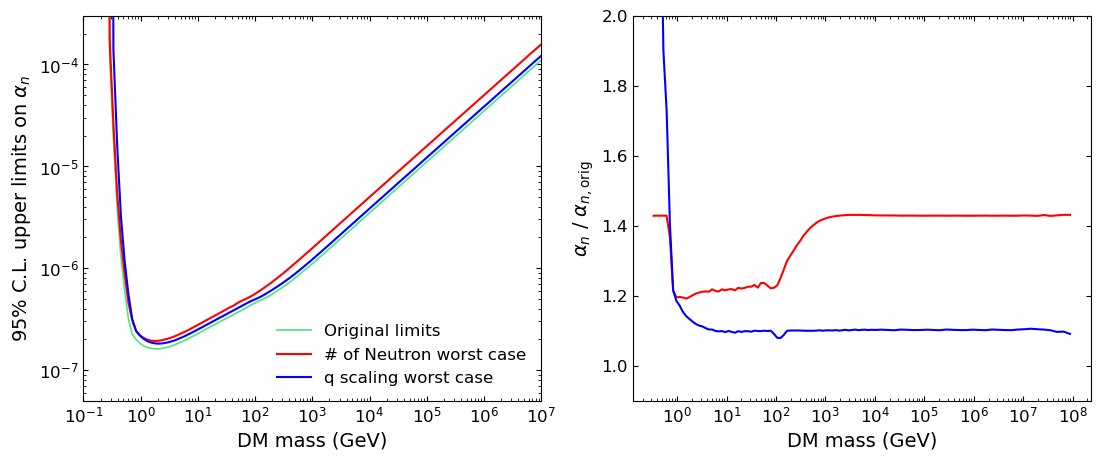

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(mxs_cl_serial[3], alpha_lims_cl_serial[3], '-', color=colors[6], linewidth=1.25, label='Original limits')
ax.loglog(mx_n_neutrons, alpha_lim_n_neutrons, 'r', label='# of Neutron worst case')
ax.loglog(mx_n_qscale, alpha_lim_n_qscale, 'b', label='q scaling worst case')

ax.set_xlim(1e-1, 1e7)
ax.set_ylim(5e-8, 3e-4)
ax.legend(frameon=False)

ax.set_xlabel('DM mass (GeV)')
ax.set_ylabel(r'95% C.L. upper limits on $\alpha_n$')

ax = axes[1]
istart = 8
ax.plot(mx_n_neutrons[istart:], alpha_lim_n_neutrons[istart:] / alpha_lims_cl_serial[3][istart:], 'r')
ax.plot(mx_n_qscale[istart:], alpha_lim_n_qscale[istart:] / alpha_lims_cl_serial[3][istart:], 'b')

ax.set_xscale('log')
ax.set_ylim(0.9, 2)

ax.set_xlabel('DM mass (GeV)')
ax.set_ylabel(r'$\alpha_n$ / $\alpha_{n, \mathrm{orig}}$')

In [92]:
alpha_lim_n_qscale[istart:] / alpha_lims_cl_serial[3][istart:]

array([7.65446407, 4.18735022, 2.4781161 , 1.89933107, 1.72757861,
       1.40346148, 1.21520353, 1.18482807, 1.17165864, 1.15354678,
       1.14167819, 1.13356071, 1.12565052, 1.11899749, 1.11452725,
       1.1119923 , 1.10719253, 1.10337536, 1.10329282, 1.09931218,
       1.09790436, 1.09893549, 1.09587647, 1.09924211, 1.09664006,
       1.09413213, 1.09861296, 1.09655674, 1.09860089, 1.09871869,
       1.09700758, 1.10006236, 1.0989675 , 1.09872389, 1.10008689,
       1.09890277, 1.09999915, 1.09072431, 1.07969308, 1.07897142,
       1.08775887, 1.09956343, 1.10039902, 1.10067637, 1.10059623,
       1.10037526, 1.100132  , 1.09966146, 1.0998285 , 1.09966513,
       1.10023315, 1.10115956, 1.09982884, 1.10089134, 1.10089163,
       1.1005462 , 1.10170446, 1.10011288, 1.10128895, 1.10242343,
       1.10084714, 1.10196316, 1.10305937, 1.10141659, 1.10244012,
       1.1029363 , 1.10171221, 1.10268187, 1.10208743, 1.10285913,
       1.10207393, 1.10129196, 1.10321846, 1.10244617, 1.10167